## 1. Business Understanding

**Operational Optimization (Drone Depots):** We will analyze customer location data using clustering techniques (K-Means and Agglomerative Hierarchical Clustering). The goal is to find the optimal geographic coordinates for drone depots that minimize flight distances and efficiently serve the surrounding customer base.

**Revenue Growth (Product Recommendations):** We will analyze historical transaction data across 20 product groups using Association Rule Mining. By identifying which product purchases act as "triggers" for buying other items, the company can build a targeted recommendation system to increase overall sales.

## 2. Data Understanding

We first load the data and inspect its structure.


In [52]:
import pandas as pd
from sklearn.cluster import KMeans

df = pd.read_csv('datasets/drone_cust_locations.csv', sep=';', na_values='NaN')

df.head()

,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298



clientid - The unique identifier for the customer

x - The x coordinate of the customer's location, when plotted into a 2D plane

y - The y coordinate of the customer's location, when plotted into a 2D plane


In [53]:
df.describe()

,clientid,x,y
count,5956.000000,5956.000000,5956.000000
mean,2978.500000,508.823177,427.554772
std,1719.493433,271.061462,289.044640
min,1.000000,0.017692,0.043285
25%,1489.750000,282.582920,170.079921
50%,2978.500000,518.100892,397.786441
75%,4467.250000,727.156497,669.982518
max,5956.000000,999.533215,999.731720


In [54]:
df_prod = pd.read_csv('datasets/drone_prod_groups.csv')

df_prod.head()

,ID,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,...,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,2,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,1,1,1,1,1
2,3,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
3,4,1,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
4,5,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,1



ID - The transaction ID

Prod1, ..., Prod20 - Binary variables indicating whether at least one product from a particular group was purchased in the transaction. A value of 1 indicates that at least one product from the group was purchased, while a value of 0 indicates that no products from the group were purchased.


## 3. Data Preparation

Changing 1 and 0 for true and false respectively.

In [55]:

df_prod = df_prod.drop(columns='ID')

df_prod = df_prod.astype("boolean")
df_prod.head()


,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,Prod10,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True
1,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,True,True,True,True,True
2,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True
3,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True
4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,True


At this point,the dataset is ready for the Apriori algorithm.

## 4. Modeling

We randomly choose three depot points and visualize them.

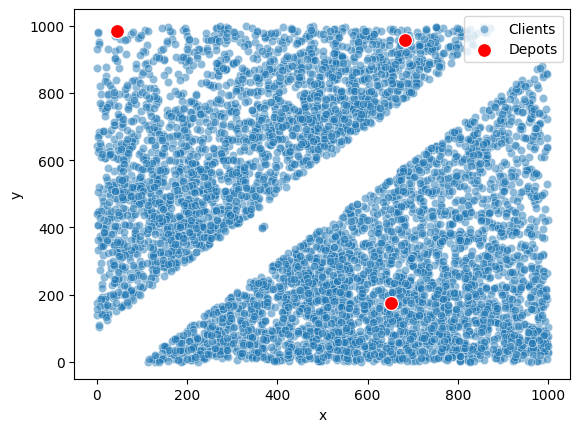

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

seed = 55
n_depots = 3
random_points = df.sample(n=n_depots, random_state=seed)

sns.scatterplot(data=df, x="x", y="y", alpha=0.5, label="Clients")
sns.scatterplot(data=random_points, x="x", y="y", color="red", s=100, label="Depots")

plt.legend()
plt.show()

Geographically, the client distribution appears to be split by a major topographical feature, resembling a river or a wide transit corridor. The clients form dense residential or commercial clusters on both sides of this divide, with the exception of two distinct clients that are in the middle of that topographical feature for some reason.

We use the K-Means algorithm to partition clients into service areas based on proximity. The algorithm mathematically calculates a centroid for each cluster, which serves as the exact, optimal location for a drone depot. 

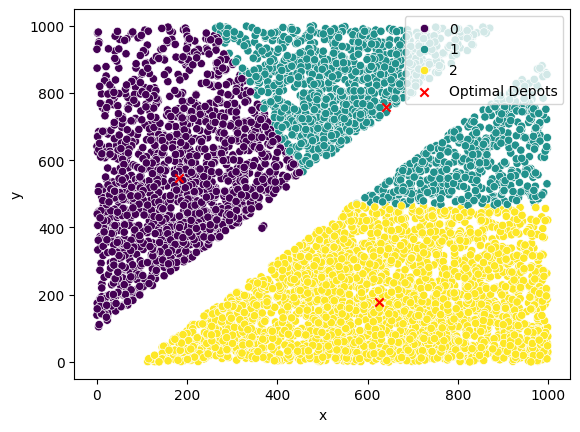

In [57]:
initial_centers = random_points[['x', 'y']].values

model = KMeans(n_clusters=n_depots, init=initial_centers, n_init=1, random_state=seed)
df['cluster'] = model.fit_predict(df[['x', 'y']])

optimal_depots = model.cluster_centers_

sns.scatterplot(data=df, x="x", y="y", hue="cluster", palette="viridis")
plt.scatter(optimal_depots[:, 0], optimal_depots[:, 1], c='red', marker='x', label="Optimal Depots")
plt.legend()
plt.show()

Let's print the first 10 rows of information on the closest depot to each client

In [67]:
model = KMeans(n_clusters=3, random_state=42)

df['closest_depot'] = model.fit_predict(df[['x', 'y']])

df.head(10)

,clientid,x,y,cluster,closest_depot
0,1,622.771572,164.857623,6,1
1,2,416.357298,630.193634,3,0
2,3,292.735020,567.333231,8,0
3,4,737.211288,166.225676,4,1
4,5,540.475375,682.912298,3,2
5,6,535.469492,318.439661,6,1
6,7,640.380050,870.833221,1,2
7,8,235.772075,359.048203,9,0
8,9,481.896884,661.491838,3,2
9,10,730.032789,312.177817,5,1


Now we try with 10 depots. Every area is colored accordingly. We did not notice any significant difference in computation time.

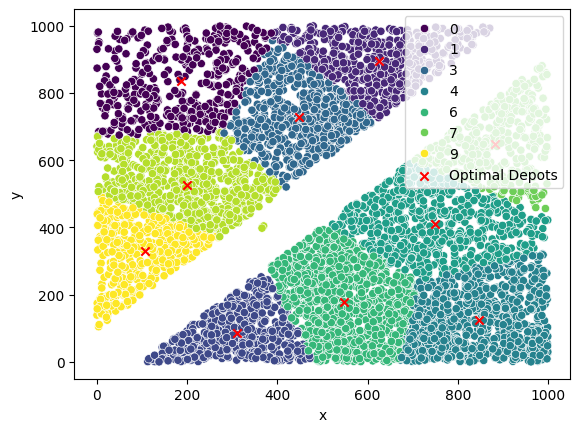

In [59]:
n_depots = 10
random_points = df.sample(n=n_depots, random_state=seed)
initial_centers = random_points[['x', 'y']].values

model = KMeans(n_clusters=n_depots, init=initial_centers, n_init=1, random_state=seed)
df['cluster'] = model.fit_predict(df[['x', 'y']])

optimal_depots = model.cluster_centers_

sns.scatterplot(data=df, x="x", y="y", hue="cluster", palette="viridis")
plt.scatter(optimal_depots[:, 0], optimal_depots[:, 1], c='red', marker='x', label="Optimal Depots")
plt.legend()
plt.show()

### Agglomerative hierarchical clustering

Next, we implemented agglomerative hierarchical clustering to compare its performance against K-means. Visually the cluster formations in the lower region of the plot remained relatively stable, but the depot locations in the upper region experienced noticeable shifts.

The computational overhead increased significantly, with execution time rising from 0.6 seconds to 1.5 seconds.

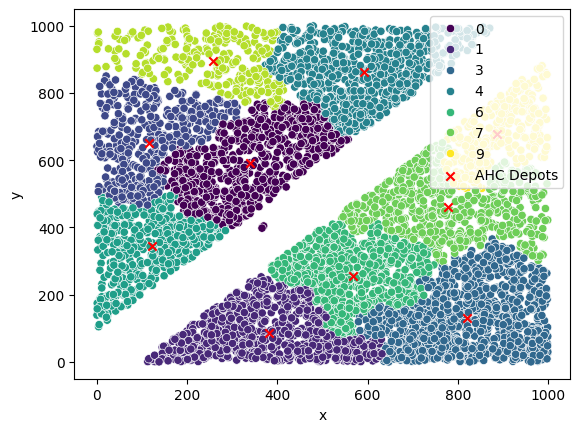

In [60]:
from sklearn.cluster import AgglomerativeClustering

hc_model = AgglomerativeClustering(n_clusters=n_depots)
df['closest_depot'] = hc_model.fit_predict(df[['x', 'y']])

# Calculating depot locations
optimal_depots = df.groupby('closest_depot')[['x', 'y']].mean().values

sns.scatterplot(data=df, x="x", y="y", hue="closest_depot", palette="viridis")
plt.scatter(optimal_depots[:, 0], optimal_depots[:, 1], c='red', marker='x', label="AHC Depots")
plt.legend()
plt.show()

### Appriori alghoritm 

We apply the algorithm to find the frequent itemsets and generate the association rules.

In [61]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(df_prod, min_support=0.1, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.10998,(Prod1)
1,0.13098,( Prod2)
2,0.10459,( Prod5)
3,0.13499,( Prod7)
4,0.16179,( Prod8)
5,0.19853,( Prod9)
6,0.10848,( Prod11)
7,0.15971,( Prod12)
8,0.14557,( Prod14)
9,0.1188,( Prod15)


## 5. Evaluation

To compare the clustering algorithms, we calculated the silhouette score for both models using 10 depots.

    K-Means: 0.368

    AHC: 0.341

K-Means achieved a slightly higher score, indicating it created more cohesive and distinct service areas. Scores in the 0.35 range suggest continuous geographic distribution with some boundary overlap, which is expected in a realistic client landscape. Because K-Means produced superior cluster separations and executed significantly faster (0.6s vs 1.5s), it is the optimal algorithm for this drone logistics network.

In [62]:
from sklearn.metrics import silhouette_score

# K-Means
kmeans_labels = model.fit_predict(df[['x', 'y']])
kmeans_silhouette = silhouette_score(df[['x', 'y']], kmeans_labels)

# AHC
ahc_labels = hc_model.fit_predict(df[['x', 'y']])
ahc_silhouette = silhouette_score(df[['x', 'y']], ahc_labels)

print(f"K-Means Silhouette Score: {kmeans_silhouette:.3f}")
print(f"AHC Silhouette Score: {ahc_silhouette:.3f}")


K-Means Silhouette Score: 0.368
AHC Silhouette Score: 0.341


To find the optimal amount of depots, we use the elbow method. K-means model shows that 3-4 depots are the perfect amount for the task.

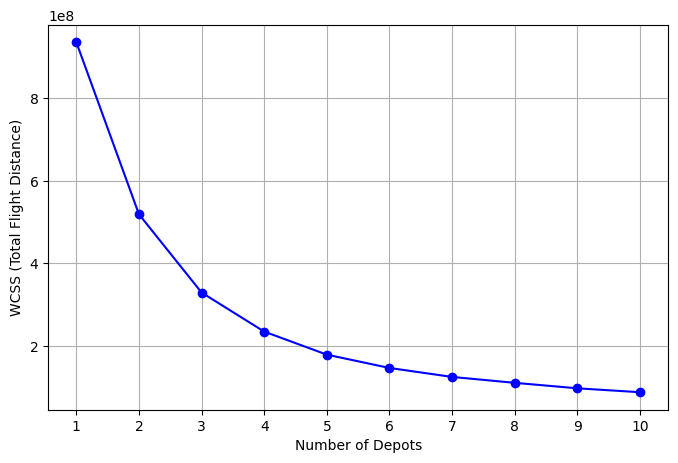

In [63]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    model = KMeans(init='random', n_clusters=i, n_init=10, random_state=42)
    model.fit(df[['x', 'y']]) 
    wcss.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Depots')
plt.ylabel('WCSS (Total Flight Distance)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### Generating association rules

In [64]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)

# sort in descending order of confidence
rules = rules.sort_values(by='confidence', ascending=False)

rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,( Prod15),( Prod9),0.11880,0.19853,0.11145,0.938131,4.725388,1.0,0.087865,12.954372,0.894663,0.541335,0.922806,0.749754
2,( Prod20),( Prod19),0.14798,0.20626,0.13476,0.910664,4.415125,1.0,0.104238,8.884845,0.907849,0.613997,0.887449,0.782007
3,( Prod19),( Prod20),0.20626,0.14798,0.13476,0.653350,4.415125,1.0,0.104238,2.457869,0.974508,0.613997,0.593144,0.782007
0,( Prod9),( Prod15),0.19853,0.11880,0.11145,0.561376,4.725388,1.0,0.087865,2.009011,0.983664,0.541335,0.502243,0.749754


The output shows the association rules in decreasing order of confidence. 



We will filter our results to only show rules with a high Lift and Confidence to ensure our business recommendations are based on strong, positively correlated purchasing behaviors.

In [65]:
sorted_rules = rules.sort_values(by=['lift', 'confidence'], ascending=[False, False])

print(sorted_rules.head(5))

  antecedents consequents  antecedent support  consequent support  support  \
1   ( Prod15)    ( Prod9)             0.11880             0.19853  0.11145   
0    ( Prod9)   ( Prod15)             0.19853             0.11880  0.11145   
2   ( Prod20)   ( Prod19)             0.14798             0.20626  0.13476   
3   ( Prod19)   ( Prod20)             0.20626             0.14798  0.13476   

   confidence      lift  representativity  leverage  conviction  \
1    0.938131  4.725388               1.0  0.087865   12.954372   
0    0.561376  4.725388               1.0  0.087865    2.009011   
2    0.910664  4.415125               1.0  0.104238    8.884845   
3    0.653350  4.415125               1.0  0.104238    2.457869   

   zhangs_metric   jaccard  certainty  kulczynski  
1       0.894663  0.541335   0.922806    0.749754  
0       0.983664  0.541335   0.502243    0.749754  
2       0.907849  0.613997   0.887449    0.782007  
3       0.974508  0.613997   0.593144    0.782007  


# 6. Deployment



### Depot Placement Strategy

Based on the Elbow Method (WCSS) and Silhouette Scores, there is a point of diminishing returns. Adding too many depots eventually provides minimal reduction in drone flight distances while drastically increasing infrastructure costs. The business should select the number of depots at the "elbow" of the inertia curve to balance flight efficiency with setup costs.


### Algorithm Comparison

K-Means proves more practical and efficient for this logistics network than AHC. It automatically calculates the exact optimal depot coordinates and generates clean, linear service boundaries, whereas AHC requires manual center computation and often produces irregular, organic zones. Additionally, K-Means is significantly faster and more scalable—executing in 0.6 seconds compared to AHC's 1.5 seconds—because AHC's requirement to calculate every pairwise client distance makes it computationally expensive for larger datasets.

### Association Rules

Based on our top-ranked rules (highest Lift and Confidence), the business should implement the following operational strategies:

1. **Store Layout & UI:** Place highly associated items next to each other physically, or feature them prominently in "Frequently Bought Together" online recommendations.
2. **Product Bundling:** Create promotional bundles for high-confidence item pairs to drive sales and increase average basket size.
3. **Inventory Syncing:** Ensure associated items are restocked and promoted together to prevent bottleneck stockouts.